In [1]:
from pathlib import Path

def find_repo_root() -> Path:
    candidates = [
        Path.cwd(),
        Path.cwd().parent,
        Path.cwd().parent.parent,
        Path("/storage/homefs/cn21m021/projects/master-thesis"),
        Path("/Users/choekyelnyungmartsang/Developer/master-thesis"),
    ]
    for p in candidates:
        if (p / "scripts" / "generate_finer_cam_panderm.py").exists():
            return p.resolve()
    raise FileNotFoundError("Could not find repo root. Set REPO_ROOT manually.")

REPO_ROOT = find_repo_root()
print("REPO_ROOT:", REPO_ROOT)

REPO_ROOT: /Users/choekyelnyungmartsang/Developer/master-thesis


In [2]:
import pandas as pd
import numpy as np
from PIL import Image
import matplotlib.pyplot as plt

pd.set_option("display.max_columns", 120)
pd.set_option("display.width", 180)

# REPO_ROOT = Path("..").resolve()

DATA_ROOT = REPO_ROOT / "data"
IMAGE_DIR = DATA_ROOT / "HAM10000" / "images"
LESION_MASK_DIR = DATA_ROOT / "HAM10000_segmentations_lesion_tschandl"
BRUSH_DIR = DATA_ROOT / "brush_annotation_masks"

BRUSH_CSV = BRUSH_DIR / "brush_annotation_summary.csv"

OUT_DIR = REPO_ROOT / "outputs" / "brush_annotation_validation"
OUT_DIR.mkdir(parents=True, exist_ok=True)

print("REPO_ROOT:", REPO_ROOT)
print("IMAGE_DIR:", IMAGE_DIR, IMAGE_DIR.exists())
print("LESION_MASK_DIR:", LESION_MASK_DIR, LESION_MASK_DIR.exists())
print("BRUSH_DIR:", BRUSH_DIR, BRUSH_DIR.exists())
print("BRUSH_CSV:", BRUSH_CSV, BRUSH_CSV.exists())

brush_df = pd.read_csv(BRUSH_CSV)

print("Brush CSV shape:", brush_df.shape)
display(brush_df)

REPO_ROOT: /Users/choekyelnyungmartsang/Developer/master-thesis
IMAGE_DIR: /Users/choekyelnyungmartsang/Developer/master-thesis/data/HAM10000/images True
LESION_MASK_DIR: /Users/choekyelnyungmartsang/Developer/master-thesis/data/HAM10000_segmentations_lesion_tschandl True
BRUSH_DIR: /Users/choekyelnyungmartsang/Developer/master-thesis/data/brush_annotation_masks True
BRUSH_CSV: /Users/choekyelnyungmartsang/Developer/master-thesis/data/brush_annotation_masks/brush_annotation_summary.csv True
Brush CSV shape: (4, 6)


,Image_ID,Annotation_ID,Label_ID,Label_Name,Mask_Filename,Stroke_Count
0,ISIC_0024306,brush_annotation_001,diagnostic_region,diagnostic_region,ISIC_0024306_diagnostic_region_brush_001.png,1
1,ISIC_0024306,brush_annotation_002,suspicious_pigment,suspicious_pigment,ISIC_0024306_suspicious_pigment_brush_002.png,3
2,ISIC_0024306,brush_annotation_003,asymmetry_region,asymmetry_region,ISIC_0024306_asymmetry_region_brush_003.png,1
3,ISIC_0024306,brush_annotation_004,artifact_ignore,artifact_ignore,ISIC_0024306_artifact_ignore_brush_004.png,2


In [3]:
def resolve_image_path(image_id: str) -> Path | None:
    candidates = [
        IMAGE_DIR / f"{image_id}.jpg",
        IMAGE_DIR / f"{image_id}.jpeg",
        IMAGE_DIR / f"{image_id}.png",
        IMAGE_DIR / f"{image_id}.JPG",
        IMAGE_DIR / f"{image_id}.JPEG",
        IMAGE_DIR / f"{image_id}.PNG",
    ]

    for candidate in candidates:
        if candidate.exists():
            return candidate

    matches = sorted(IMAGE_DIR.glob(f"{image_id}.*"))
    if matches:
        return matches[0]

    return None


def resolve_lesion_mask_path(image_id: str) -> Path | None:
    candidates = [
        LESION_MASK_DIR / f"{image_id}_segmentation.png",
        LESION_MASK_DIR / f"{image_id}.png",
    ]

    for candidate in candidates:
        if candidate.exists():
            return candidate

    matches = sorted(LESION_MASK_DIR.glob(f"{image_id}*"))
    if matches:
        return matches[0]

    return None


def resolve_brush_mask_path(mask_filename: str) -> Path:
    return BRUSH_DIR / mask_filename


brush_df["image_path"] = brush_df["Image_ID"].map(resolve_image_path)
brush_df["lesion_mask_path"] = brush_df["Image_ID"].map(resolve_lesion_mask_path)
brush_df["brush_mask_path"] = brush_df["Mask_Filename"].map(resolve_brush_mask_path)

brush_df["image_exists"] = brush_df["image_path"].map(lambda p: p is not None and Path(p).exists())
brush_df["lesion_mask_exists"] = brush_df["lesion_mask_path"].map(lambda p: p is not None and Path(p).exists())
brush_df["brush_mask_exists"] = brush_df["brush_mask_path"].map(lambda p: Path(p).exists())

display(brush_df[[
    "Image_ID",
    "Label_Name",
    "Mask_Filename",
    "Stroke_Count",
    "image_exists",
    "lesion_mask_exists",
    "brush_mask_exists",
    "image_path",
    "lesion_mask_path",
    "brush_mask_path",
]])

,Image_ID,Label_Name,Mask_Filename,Stroke_Count,image_exists,lesion_mask_exists,brush_mask_exists,image_path,lesion_mask_path,brush_mask_path
0,ISIC_0024306,diagnostic_region,ISIC_0024306_diagnostic_region_brush_001.png,1,True,True,True,/Users/choekyelnyungmartsang/Developer/master-...,/Users/choekyelnyungmartsang/Developer/master-...,/Users/choekyelnyungmartsang/Developer/master-...
1,ISIC_0024306,suspicious_pigment,ISIC_0024306_suspicious_pigment_brush_002.png,3,True,True,True,/Users/choekyelnyungmartsang/Developer/master-...,/Users/choekyelnyungmartsang/Developer/master-...,/Users/choekyelnyungmartsang/Developer/master-...
2,ISIC_0024306,asymmetry_region,ISIC_0024306_asymmetry_region_brush_003.png,1,True,True,True,/Users/choekyelnyungmartsang/Developer/master-...,/Users/choekyelnyungmartsang/Developer/master-...,/Users/choekyelnyungmartsang/Developer/master-...
3,ISIC_0024306,artifact_ignore,ISIC_0024306_artifact_ignore_brush_004.png,2,True,True,True,/Users/choekyelnyungmartsang/Developer/master-...,/Users/choekyelnyungmartsang/Developer/master-...,/Users/choekyelnyungmartsang/Developer/master-...


In [4]:
def load_rgb(path: Path) -> np.ndarray:
    return np.array(Image.open(path).convert("RGB"))


def load_gray(path: Path) -> np.ndarray:
    return np.array(Image.open(path).convert("L"))


def binarize_mask(mask: np.ndarray) -> np.ndarray:
    return mask > 0


def resize_mask_nearest(mask: np.ndarray, target_hw: tuple[int, int]) -> np.ndarray:
    target_h, target_w = target_hw
    pil = Image.fromarray(mask.astype(np.uint8))
    pil = pil.resize((target_w, target_h), resample=Image.Resampling.NEAREST)
    return np.array(pil)


def compute_binary_metrics(pred: np.ndarray, gt: np.ndarray) -> dict:
    pred = pred.astype(bool)
    gt = gt.astype(bool)

    pred_sum = int(pred.sum())
    gt_sum = int(gt.sum())
    intersection = int(np.logical_and(pred, gt).sum())
    union = int(np.logical_or(pred, gt).sum())

    dice = np.nan
    iou = np.nan
    precision = np.nan
    recall = np.nan

    if pred_sum + gt_sum > 0:
        dice = 2 * intersection / (pred_sum + gt_sum)

    if union > 0:
        iou = intersection / union

    if pred_sum > 0:
        precision = intersection / pred_sum

    if gt_sum > 0:
        recall = intersection / gt_sum

    return {
        "pred_pixels": pred_sum,
        "gt_pixels": gt_sum,
        "intersection_pixels": intersection,
        "union_pixels": union,
        "dice": dice,
        "iou": iou,
        "precision": precision,
        "recall": recall,
    }


def mask_unique_summary(mask: np.ndarray) -> dict:
    uniq = np.unique(mask)
    preview = uniq[:20].tolist()

    is_binary_01 = set(uniq.tolist()).issubset({0, 1})
    is_binary_0255 = set(uniq.tolist()).issubset({0, 255})
    is_binary_like = is_binary_01 or is_binary_0255

    return {
        "n_unique_values": len(uniq),
        "min_value": int(uniq.min()),
        "max_value": int(uniq.max()),
        "is_binary_like": bool(is_binary_like),
        "unique_values_preview": str(preview),
    }


def get_bbox(mask_bin: np.ndarray):
    ys, xs = np.where(mask_bin)

    if len(xs) == 0:
        return None

    return {
        "x_min": int(xs.min()),
        "y_min": int(ys.min()),
        "x_max": int(xs.max()),
        "y_max": int(ys.max()),
        "width": int(xs.max() - xs.min() + 1),
        "height": int(ys.max() - ys.min() + 1),
    }

In [5]:
rows = []

for _, row in brush_df.iterrows():
    image_id = row["Image_ID"]
    label_name = row["Label_Name"]
    mask_filename = row["Mask_Filename"]

    image_path = row["image_path"]
    lesion_mask_path = row["lesion_mask_path"]
    brush_mask_path = row["brush_mask_path"]

    result = {
        "Image_ID": image_id,
        "Annotation_ID": row["Annotation_ID"],
        "Label_ID": row["Label_ID"],
        "Label_Name": label_name,
        "Mask_Filename": mask_filename,
        "Stroke_Count": row["Stroke_Count"],
        "image_exists": bool(row["image_exists"]),
        "lesion_mask_exists": bool(row["lesion_mask_exists"]),
        "brush_mask_exists": bool(row["brush_mask_exists"]),
    }

    if not row["image_exists"] or not row["brush_mask_exists"]:
        rows.append(result)
        continue

    rgb = load_rgb(image_path)
    brush_mask = load_gray(brush_mask_path)

    result["image_h"] = rgb.shape[0]
    result["image_w"] = rgb.shape[1]
    result["brush_h"] = brush_mask.shape[0]
    result["brush_w"] = brush_mask.shape[1]
    result["image_brush_size_match"] = (rgb.shape[0] == brush_mask.shape[0]) and (rgb.shape[1] == brush_mask.shape[1])

    result.update({
        f"brush_{k}": v for k, v in mask_unique_summary(brush_mask).items()
    })

    brush_bin = binarize_mask(brush_mask)
    result["brush_foreground_pixels"] = int(brush_bin.sum())
    result["brush_foreground_ratio"] = float(brush_bin.mean())
    result["brush_empty"] = int(brush_bin.sum() == 0)

    bbox = get_bbox(brush_bin)
    if bbox is not None:
        result.update({f"brush_bbox_{k}": v for k, v in bbox.items()})

    if row["lesion_mask_exists"]:
        lesion_mask = load_gray(lesion_mask_path)

        result["lesion_h"] = lesion_mask.shape[0]
        result["lesion_w"] = lesion_mask.shape[1]
        result["image_lesion_size_match"] = (rgb.shape[0] == lesion_mask.shape[0]) and (rgb.shape[1] == lesion_mask.shape[1])

        if lesion_mask.shape != brush_mask.shape:
            lesion_mask_for_metrics = resize_mask_nearest(lesion_mask, brush_mask.shape)
        else:
            lesion_mask_for_metrics = lesion_mask

        lesion_bin = binarize_mask(lesion_mask_for_metrics)
        metrics = compute_binary_metrics(brush_bin, lesion_bin)
        result.update({f"lesion_{k}": v for k, v in metrics.items()})

    rows.append(result)

validation_df = pd.DataFrame(rows)

display(validation_df)

validation_csv = OUT_DIR / "brush_annotation_validation_summary.csv"
validation_df.to_csv(validation_csv, index=False)

print("Saved:", validation_csv)

,Image_ID,Annotation_ID,Label_ID,Label_Name,Mask_Filename,Stroke_Count,image_exists,lesion_mask_exists,brush_mask_exists,image_h,image_w,brush_h,brush_w,image_brush_size_match,brush_n_unique_values,brush_min_value,brush_max_value,brush_is_binary_like,brush_unique_values_preview,brush_foreground_pixels,brush_foreground_ratio,brush_empty,brush_bbox_x_min,brush_bbox_y_min,brush_bbox_x_max,brush_bbox_y_max,brush_bbox_width,brush_bbox_height,lesion_h,lesion_w,image_lesion_size_match,lesion_pred_pixels,lesion_gt_pixels,lesion_intersection_pixels,lesion_union_pixels,lesion_dice,lesion_iou,lesion_precision,lesion_recall
0,ISIC_0024306,brush_annotation_001,diagnostic_region,diagnostic_region,ISIC_0024306_diagnostic_region_brush_001.png,1,True,True,True,450,600,450,600,True,2,0,255,True,"[0, 255]",7735,0.028648,0,289,155,392,260,104,106,450,600,True,7735,92549,7735,92549,0.154262,0.083577,1.000000,0.083577
1,ISIC_0024306,brush_annotation_002,suspicious_pigment,suspicious_pigment,ISIC_0024306_suspicious_pigment_brush_002.png,3,True,True,True,450,600,450,600,True,2,0,255,True,"[0, 255]",2612,0.009674,0,285,81,416,310,132,230,450,600,True,2612,92549,2612,92549,0.054896,0.028223,1.000000,0.028223
2,ISIC_0024306,brush_annotation_003,asymmetry_region,asymmetry_region,ISIC_0024306_asymmetry_region_brush_003.png,1,True,True,True,450,600,450,600,True,2,0,255,True,"[0, 255]",749,0.002774,0,277,163,306,219,30,57,450,600,True,749,92549,749,92549,0.016056,0.008093,1.000000,0.008093
3,ISIC_0024306,brush_annotation_004,artifact_ignore,artifact_ignore,ISIC_0024306_artifact_ignore_brush_004.png,2,True,True,True,450,600,450,600,True,2,0,255,True,"[0, 255]",6863,0.025419,0,158,0,386,280,229,281,450,600,True,6863,92549,5441,93971,0.109464,0.057901,0.792802,0.058790


Saved: /Users/choekyelnyungmartsang/Developer/master-thesis/outputs/brush_annotation_validation/brush_annotation_validation_summary.csv


In [6]:
summary = {
    "n_rows": len(validation_df),
    "n_images": validation_df["Image_ID"].nunique(),
    "missing_images": int((validation_df["image_exists"] == False).sum()),
    "missing_brush_masks": int((validation_df["brush_mask_exists"] == False).sum()),
    "missing_lesion_masks": int((validation_df["lesion_mask_exists"] == False).sum()),
    "brush_size_mismatches": int((validation_df["image_brush_size_match"] == False).sum()),
    "empty_brush_masks": int(validation_df.get("brush_empty", pd.Series(dtype=int)).fillna(0).sum()),
}

if "brush_is_binary_like" in validation_df.columns:
    summary["non_binary_like_brush_masks"] = int((validation_df["brush_is_binary_like"] == False).sum())

summary_df = pd.DataFrame([summary])
display(summary_df)

print("Label counts:")
display(validation_df["Label_Name"].value_counts())

if "lesion_dice" in validation_df.columns:
    print("Overlap with lesion mask:")
    display(validation_df[[
        "Image_ID",
        "Label_Name",
        "Stroke_Count",
        "brush_foreground_pixels",
        "brush_foreground_ratio",
        "lesion_dice",
        "lesion_iou",
        "lesion_precision",
        "lesion_recall",
    ]])

,n_rows,n_images,missing_images,missing_brush_masks,missing_lesion_masks,brush_size_mismatches,empty_brush_masks,non_binary_like_brush_masks
0,4,1,0,0,0,0,0,0


Label counts:


Label_Name
diagnostic_region     1
suspicious_pigment    1
asymmetry_region      1
artifact_ignore       1
Name: count, dtype: int64

Overlap with lesion mask:


,Image_ID,Label_Name,Stroke_Count,brush_foreground_pixels,brush_foreground_ratio,lesion_dice,lesion_iou,lesion_precision,lesion_recall
0,ISIC_0024306,diagnostic_region,1,7735,0.028648,0.154262,0.083577,1.000000,0.083577
1,ISIC_0024306,suspicious_pigment,3,2612,0.009674,0.054896,0.028223,1.000000,0.028223
2,ISIC_0024306,asymmetry_region,1,749,0.002774,0.016056,0.008093,1.000000,0.008093
3,ISIC_0024306,artifact_ignore,2,6863,0.025419,0.109464,0.057901,0.792802,0.058790


In [7]:
import matplotlib.pyplot as plt
import matplotlib.colors as mcolors

def build_label_color_map(label_names):
    cmap = plt.get_cmap("tab20")
    label_names = sorted([str(x) for x in label_names])

    colors = {}
    for idx, label_name in enumerate(label_names):
        rgb_float = cmap(idx % cmap.N)[:3]
        rgb_uint8 = tuple(int(255 * c) for c in rgb_float)
        colors[label_name] = rgb_uint8

    return colors

LABEL_COLORS = build_label_color_map(brush_df["Label_Name"].unique())


def overlay_mask(rgb: np.ndarray, mask_bin: np.ndarray, color=(255, 0, 0), alpha=0.45) -> np.ndarray:
    out = rgb.astype(np.float32).copy()
    color_arr = np.array(color, dtype=np.float32)

    mask = mask_bin.astype(bool)
    out[mask] = (1 - alpha) * out[mask] + alpha * color_arr

    return np.clip(out, 0, 255).astype(np.uint8)


def make_combined_annotation_mask(image_id: str):
    image_rows = brush_df[brush_df["Image_ID"] == image_id].copy()

    if len(image_rows) == 0:
        return None

    image_path = image_rows.iloc[0]["image_path"]
    rgb = load_rgb(image_path)
    combined = np.zeros_like(rgb)

    for _, row in image_rows.iterrows():
        mask = load_gray(row["brush_mask_path"])
        if mask.shape != rgb.shape[:2]:
            mask = resize_mask_nearest(mask, rgb.shape[:2])

        mask_bin = binarize_mask(mask)
        color = LABEL_COLORS.get(row["Label_Name"], (255, 255, 0))

        combined[mask_bin] = color

    return combined


def show_single_annotation_row(row, save=True):
    image_id = row["Image_ID"]
    label_name = row["Label_Name"]

    rgb = load_rgb(row["image_path"])
    brush_mask = load_gray(row["brush_mask_path"])

    if brush_mask.shape != rgb.shape[:2]:
        brush_mask = resize_mask_nearest(brush_mask, rgb.shape[:2])

    brush_bin = binarize_mask(brush_mask)
    brush_color = LABEL_COLORS.get(label_name, (255, 255, 0))
    rgb_brush_overlay = overlay_mask(rgb, brush_bin, color=brush_color, alpha=0.45)

    lesion_exists = row["lesion_mask_path"] is not None and Path(row["lesion_mask_path"]).exists()

    if lesion_exists:
        lesion_mask = load_gray(row["lesion_mask_path"])
        if lesion_mask.shape != rgb.shape[:2]:
            lesion_mask = resize_mask_nearest(lesion_mask, rgb.shape[:2])
        lesion_bin = binarize_mask(lesion_mask)
        rgb_lesion_overlay = overlay_mask(rgb, lesion_bin, color=(0, 255, 0), alpha=0.30)
        rgb_both_overlay = overlay_mask(rgb_lesion_overlay, brush_bin, color=brush_color, alpha=0.45)
    else:
        lesion_mask = np.zeros(rgb.shape[:2], dtype=np.uint8)
        lesion_bin = np.zeros(rgb.shape[:2], dtype=bool)
        rgb_lesion_overlay = rgb.copy()
        rgb_both_overlay = rgb_brush_overlay.copy()

    fig, axes = plt.subplots(1, 6, figsize=(22, 4))

    axes[0].imshow(rgb)
    axes[0].set_title("RGB image")

    axes[1].imshow(lesion_bin, cmap="gray")
    axes[1].set_title("Lesion mask")

    axes[2].imshow(brush_bin, cmap="gray")
    axes[2].set_title(f"Brush mask\n{label_name}")

    axes[3].imshow(rgb_lesion_overlay)
    axes[3].set_title("RGB + lesion")

    axes[4].imshow(rgb_brush_overlay)
    axes[4].set_title("RGB + brush")

    axes[5].imshow(rgb_both_overlay)
    axes[5].set_title("RGB + lesion + brush")

    for ax in axes:
        ax.axis("off")

    fig.suptitle(
        f"{image_id} | {label_name} | strokes: {row['Stroke_Count']} | file: {row['Mask_Filename']}",
        fontsize=13,
        fontweight="bold",
    )

    plt.tight_layout()

    if save:
        out_path = OUT_DIR / f"{image_id}_{label_name}_validation_panel.png"
        plt.savefig(out_path, dpi=180, bbox_inches="tight")
        print("Saved:", out_path)

    plt.show()

Saved: /Users/choekyelnyungmartsang/Developer/master-thesis/outputs/brush_annotation_validation/ISIC_0024306_diagnostic_region_validation_panel.png


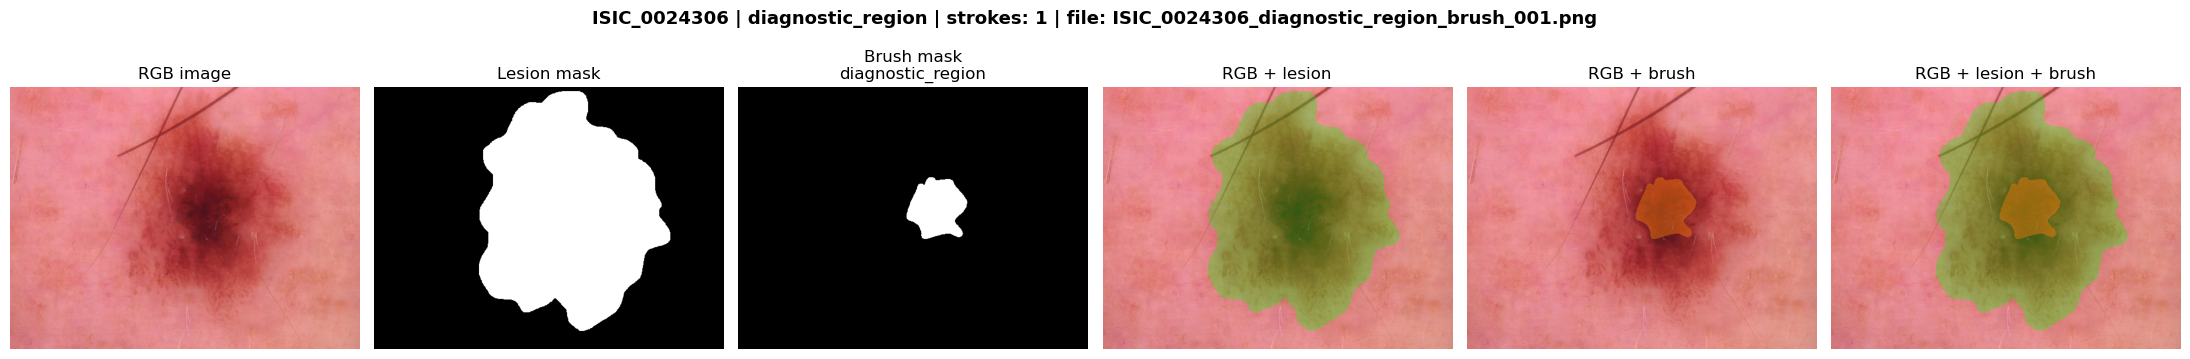

Saved: /Users/choekyelnyungmartsang/Developer/master-thesis/outputs/brush_annotation_validation/ISIC_0024306_suspicious_pigment_validation_panel.png


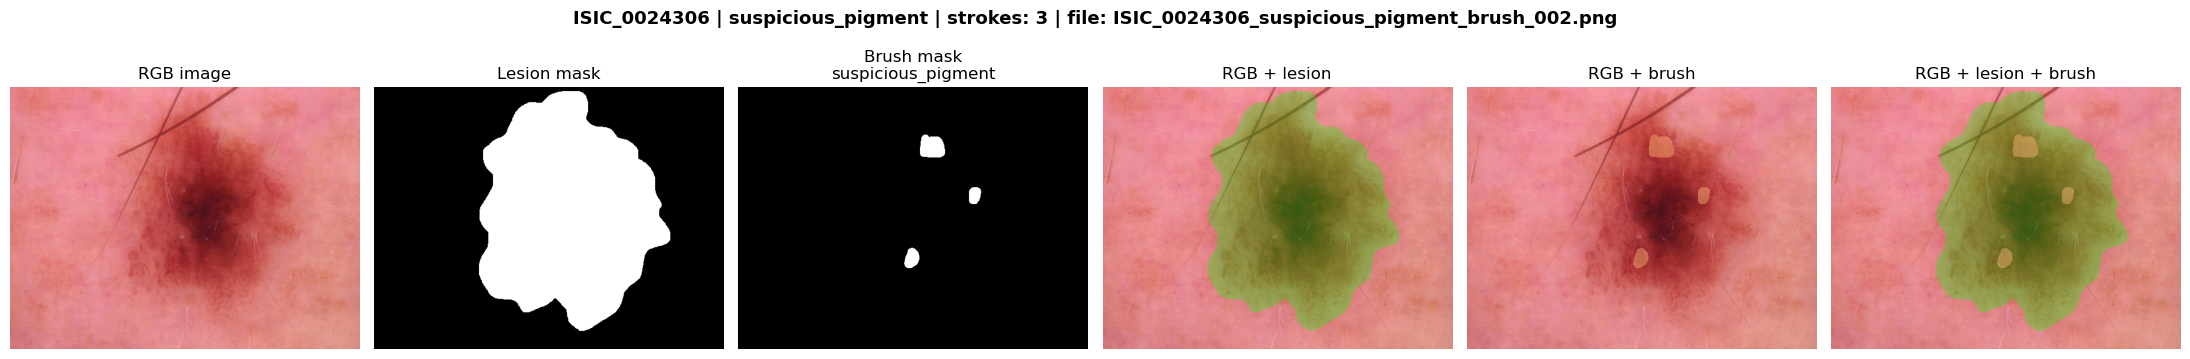

Saved: /Users/choekyelnyungmartsang/Developer/master-thesis/outputs/brush_annotation_validation/ISIC_0024306_asymmetry_region_validation_panel.png


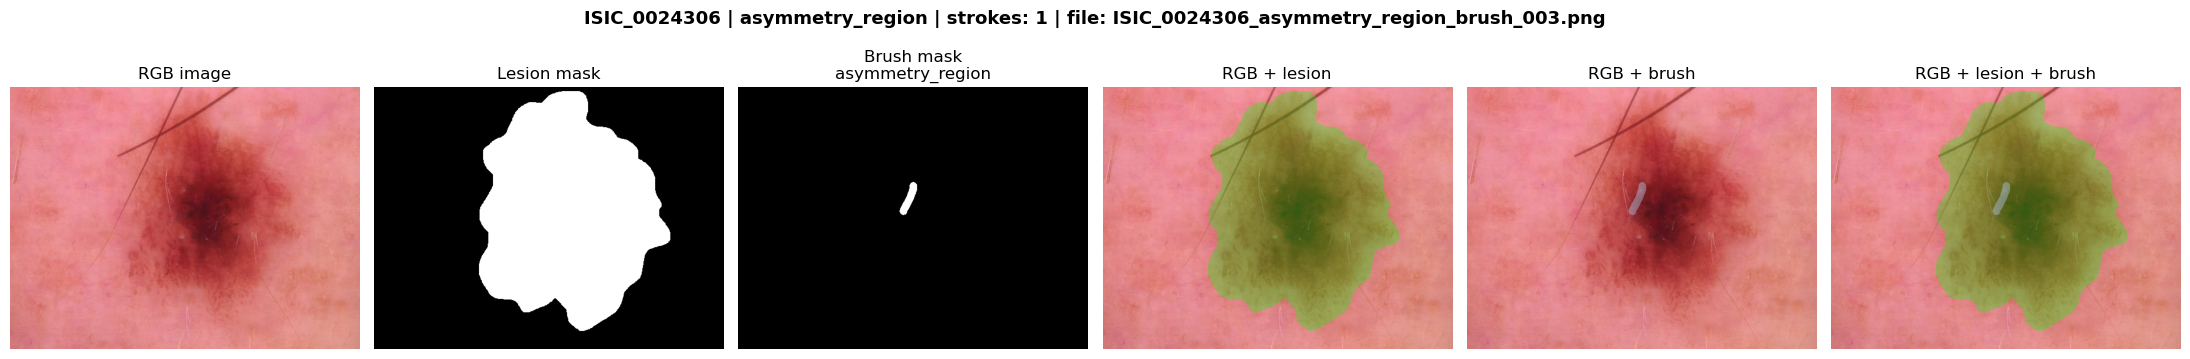

Saved: /Users/choekyelnyungmartsang/Developer/master-thesis/outputs/brush_annotation_validation/ISIC_0024306_artifact_ignore_validation_panel.png


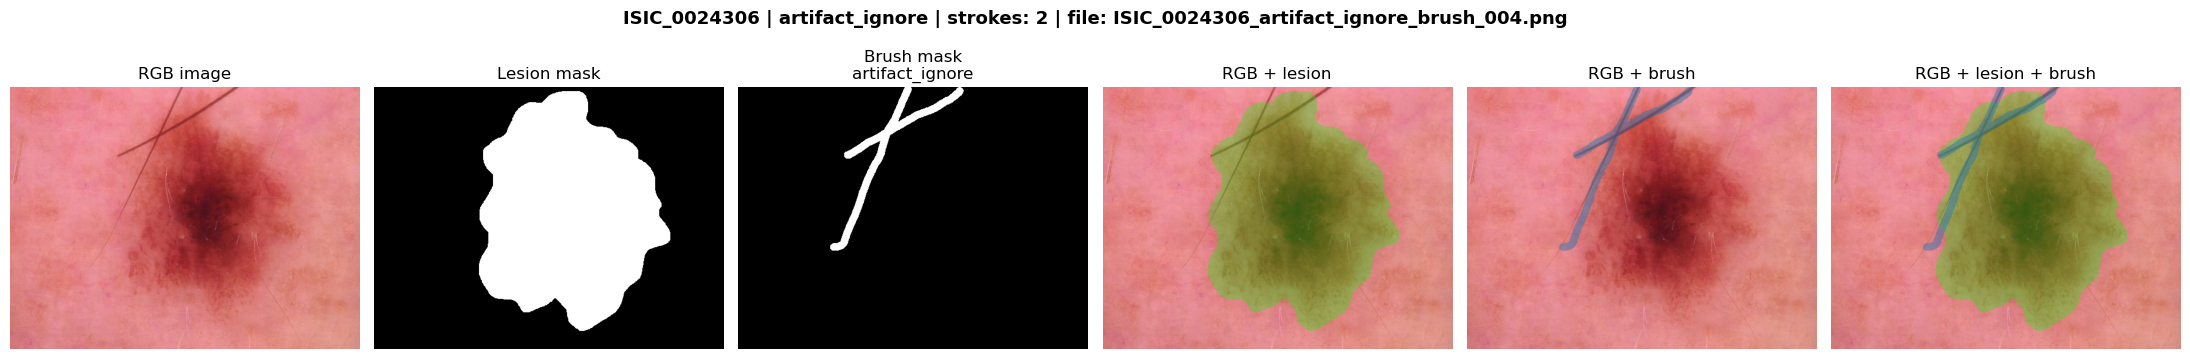

In [8]:
for _, row in brush_df.iterrows():
    show_single_annotation_row(row, save=True)

Saved: /Users/choekyelnyungmartsang/Developer/master-thesis/outputs/brush_annotation_validation/ISIC_0024306_combined_brush_validation.png


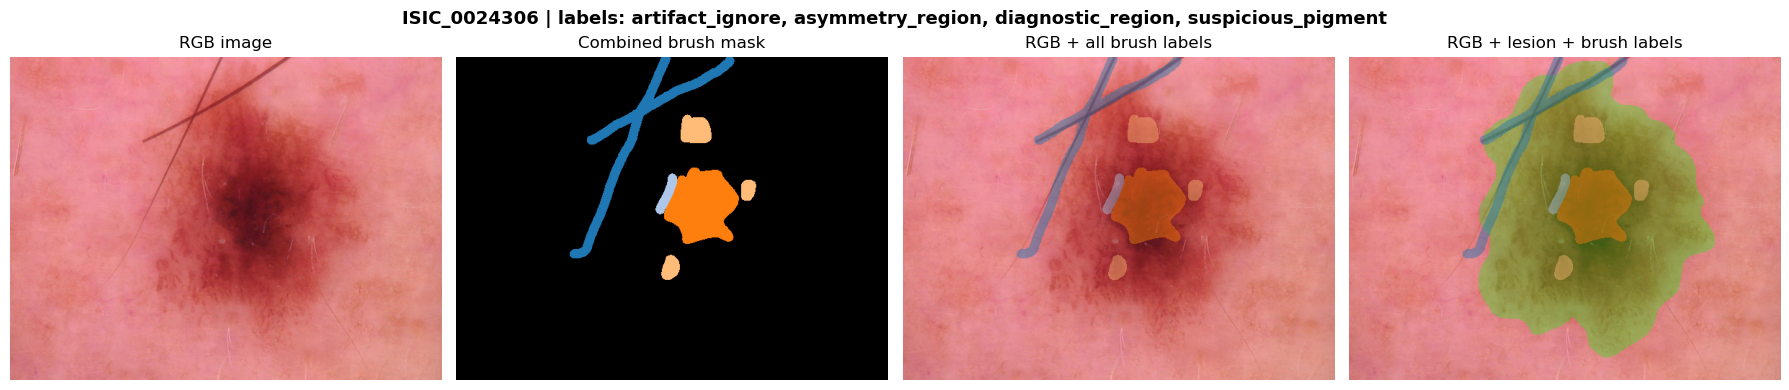

In [9]:
for image_id in brush_df["Image_ID"].unique():
    image_rows = brush_df[brush_df["Image_ID"] == image_id].copy()
    image_path = image_rows.iloc[0]["image_path"]

    rgb = load_rgb(image_path)
    combined_color_mask = make_combined_annotation_mask(image_id)

    if combined_color_mask is None:
        continue

    combined_bin = combined_color_mask.sum(axis=-1) > 0
    combined_overlay = rgb.copy().astype(np.float32)
    combined_overlay[combined_bin] = 0.55 * combined_overlay[combined_bin] + 0.45 * combined_color_mask[combined_bin]
    combined_overlay = np.clip(combined_overlay, 0, 255).astype(np.uint8)

    lesion_path = image_rows.iloc[0]["lesion_mask_path"]
    if lesion_path is not None and Path(lesion_path).exists():
        lesion_mask = load_gray(lesion_path)
        if lesion_mask.shape != rgb.shape[:2]:
            lesion_mask = resize_mask_nearest(lesion_mask, rgb.shape[:2])
        lesion_bin = binarize_mask(lesion_mask)
        lesion_overlay = overlay_mask(rgb, lesion_bin, color=(0, 255, 0), alpha=0.30)
        combined_with_lesion = lesion_overlay.copy().astype(np.float32)
        combined_with_lesion[combined_bin] = 0.55 * combined_with_lesion[combined_bin] + 0.45 * combined_color_mask[combined_bin]
        combined_with_lesion = np.clip(combined_with_lesion, 0, 255).astype(np.uint8)
    else:
        combined_with_lesion = combined_overlay

    fig, axes = plt.subplots(1, 4, figsize=(18, 4))

    axes[0].imshow(rgb)
    axes[0].set_title("RGB image")

    axes[1].imshow(combined_color_mask)
    axes[1].set_title("Combined brush mask")

    axes[2].imshow(combined_overlay)
    axes[2].set_title("RGB + all brush labels")

    axes[3].imshow(combined_with_lesion)
    axes[3].set_title("RGB + lesion + brush labels")

    for ax in axes:
        ax.axis("off")

    labels = ", ".join(sorted(image_rows["Label_Name"].unique()))
    fig.suptitle(f"{image_id} | labels: {labels}", fontsize=13, fontweight="bold")

    plt.tight_layout()

    out_path = OUT_DIR / f"{image_id}_combined_brush_validation.png"
    plt.savefig(out_path, dpi=180, bbox_inches="tight")
    print("Saved:", out_path)

    plt.show()

In [10]:
for _, row in brush_df.iterrows():
    mask = load_gray(row["brush_mask_path"])
    uniq = np.unique(mask)

    print("=" * 80)
    print(row["Image_ID"], row["Label_Name"], row["Mask_Filename"])
    print("shape:", mask.shape)
    print("dtype:", mask.dtype)
    print("n unique:", len(uniq))
    print("min:", int(uniq.min()), "max:", int(uniq.max()))
    print("unique preview:", uniq[:30].tolist())

    if len(uniq) > 2:
        print("NOTE: mask contains antialiasing or grayscale edge values")
        print("For training, use mask > 0 or patch exporter to force 0 and 255")

ISIC_0024306 diagnostic_region ISIC_0024306_diagnostic_region_brush_001.png
shape: (450, 600)
dtype: uint8
n unique: 2
min: 0 max: 255
unique preview: [0, 255]
ISIC_0024306 suspicious_pigment ISIC_0024306_suspicious_pigment_brush_002.png
shape: (450, 600)
dtype: uint8
n unique: 2
min: 0 max: 255
unique preview: [0, 255]
ISIC_0024306 asymmetry_region ISIC_0024306_asymmetry_region_brush_003.png
shape: (450, 600)
dtype: uint8
n unique: 2
min: 0 max: 255
unique preview: [0, 255]
ISIC_0024306 artifact_ignore ISIC_0024306_artifact_ignore_brush_004.png
shape: (450, 600)
dtype: uint8
n unique: 2
min: 0 max: 255
unique preview: [0, 255]


In [ ]:
# BIN_OUT_DIR = OUT_DIR / "binarized_brush_masks"
# BIN_OUT_DIR.mkdir(parents=True, exist_ok=True)

# for _, row in brush_df.iterrows():
#     mask = load_gray(row["brush_mask_path"])
#     mask_bin_255 = (mask > 0).astype(np.uint8) * 255

#     out_path = BIN_OUT_DIR / row["Mask_Filename"]
#     Image.fromarray(mask_bin_255).save(out_path)

# print("Saved binarized masks to:", BIN_OUT_DIR)

# required_pass_cols = [
#     "image_exists",
#     "brush_mask_exists",
#     "image_brush_size_match",
#     "brush_is_binary_like",
# ]

failed = validation_df[
    (validation_df["image_exists"] != True) |
    (validation_df["brush_mask_exists"] != True) |
    (validation_df["image_brush_size_match"] != True) |
    (validation_df["brush_is_binary_like"] != True) |
    (validation_df["brush_empty"] != 0)
].copy()

print("Failed rows:", len(failed))

if len(failed) > 0:
    display(failed[[
        "Image_ID",
        "Label_Name",
        "Mask_Filename",
        "image_exists",
        "brush_mask_exists",
        "image_brush_size_match",
        "brush_is_binary_like",
        "brush_empty",
    ]])
else:
    print("All brush export integrity checks passed.")

Failed rows: 0
All brush export integrity checks passed.
